**1. Library import and data loader**
- Đọc dữ liệu về cá
- Đọc dữ liệu về môi trường

In [35]:
import torch
import torch.nn as nn 
import torch.nn.functional as F
import numpy as np 
import pandas as pd
import xarray as xr
from pathlib import Path
from sklearn.preprocessing import MultiLabelBinarizer

In [36]:
# Load presence-only fish points ---
fish_path = "../../dataset/obis_gbif_asia_2020_2025_trich_thu_ngu.csv"
fish_df = pd.read_csv(fish_path)

# Rename columns
if "decimalLatitude" in fish_df.columns:
    fish_df = fish_df.rename(columns={"decimalLatitude": "lat", "decimalLongitude": "lon"})

# Parse date
fish_df["eventDate"] = fish_df["eventDate"].astype(str).str.strip()
fish_df["datetime"] = pd.to_datetime(fish_df["eventDate"], errors="coerce", format="mixed", utc=True)
fish_df["date"] = fish_df["datetime"].dt.date
fish_df = fish_df.dropna(subset=["lat", "lon", "date", "fish_type"])

print(f"Len fish_df: {len(fish_df)}")
print((fish_df['occurrenceStatus'] == 1.0).sum())
print(f"Genus distribution:\n{fish_df['fish_type'].value_counts()}")
fish_df.head()

Len fish_df: 2359
2359
Genus distribution:
fish_type
Ca Trich    1720
Ca Ngu       330
Ca Thu       309
Name: count, dtype: int64


,fish_type,genus,lat,lon,eventDate,occurrenceStatus,source,datetime,date
0,Ca Trich,Clupea,-9.446171,46.210988,2023-04-24T04:55:32Z,1.0,obis,2023-04-24 04:55:32+00:00,2023-04-24
1,Ca Trich,Clupea,8.848100,119.932083,2023-04-14,1.0,obis,2023-04-14 00:00:00+00:00,2023-04-14
2,Ca Trich,Clupea,8.804517,119.825967,2023-04-15,1.0,obis,2023-04-15 00:00:00+00:00,2023-04-15
3,Ca Trich,Clupea,-9.369519,46.450737,2023-03-27T05:23:53Z,1.0,obis,2023-03-27 05:23:53+00:00,2023-03-27
4,Ca Trich,Clupea,21.756580,89.223058,2023-01-08,1.0,obis,2023-01-08 00:00:00+00:00,2023-01-08


So, the number of occurrenceStatus of this dataframe is 1.0. So that this dataset is presence-only

In [37]:
print(fish_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2359 entries, 0 to 2379
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   fish_type         2359 non-null   object             
 1   genus             2285 non-null   object             
 2   lat               2359 non-null   float64            
 3   lon               2359 non-null   float64            
 4   eventDate         2359 non-null   object             
 5   occurrenceStatus  2359 non-null   float64            
 6   source            2359 non-null   object             
 7   datetime          2359 non-null   datetime64[ns, UTC]
 8   date              2359 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(3), object(5)
memory usage: 184.3+ KB
None


1.2 Đọc dữ liệu về môi trường

In [38]:
import xarray as xr
from pathlib import Path
# Load multiple environmental NetCDF files for years 2021-2025
env_base_dir = Path("../../dataset/env_copernius")
years = [2021, 2022, 2023, 2024, 2025]
env_files = {
    "thetao": "phy_thetao_{year}.nc",
    "so": "phy_so_{year}.nc",
    "uo_vo": "phy_uo_vo_{year}.nc",
    "mlotst": "phy_mlotst_{year}.nc",
    "chl": "bio_chl_phyc_{year}.nc",
    "o2": "bio_o2_{year}.nc",
}
env_datasets = {}

for var_name, template in env_files.items():
    yearly_datasets = []
    for year in years:
        filepath = env_base_dir / f"env_{year}" / template.format(year=year)
        if filepath.exists():
            try:
                ds = xr.open_dataset(filepath)
                yearly_datasets.append(ds)
                print(f"✓ Loaded {var_name} {year}: {filepath.name}")
            except Exception as e:
                print(f"✗ Failed to load {var_name} {year}: {e}")
        else:
            print(f"✗ File not found: {filepath}")
    if yearly_datasets:
        if len(yearly_datasets) == 1:
            env_datasets[var_name] = yearly_datasets[0]
        else:
            try:
                env_datasets[var_name] = xr.concat(yearly_datasets, dim="time")
            except Exception as e:
                print(f"✗ Failed to concat {var_name} across years: {e}")
    else:
        print(f"⚠️ No data loaded for {var_name} (2021-2025)")
print(f"\nTotal environmental datasets loaded: {len(env_datasets)}")

✗ File not found: ../../dataset/env_copernius/env_2021/phy_thetao_2021.nc
✓ Loaded thetao 2022: phy_thetao_2022.nc
✓ Loaded thetao 2023: phy_thetao_2023.nc
✓ Loaded thetao 2024: phy_thetao_2024.nc
✓ Loaded thetao 2025: phy_thetao_2025.nc
✗ File not found: ../../dataset/env_copernius/env_2021/phy_so_2021.nc
✓ Loaded so 2022: phy_so_2022.nc
✓ Loaded so 2023: phy_so_2023.nc
✓ Loaded so 2024: phy_so_2024.nc
✓ Loaded so 2025: phy_so_2025.nc
✗ File not found: ../../dataset/env_copernius/env_2021/phy_uo_vo_2021.nc
✓ Loaded uo_vo 2022: phy_uo_vo_2022.nc
✓ Loaded uo_vo 2023: phy_uo_vo_2023.nc
✓ Loaded uo_vo 2024: phy_uo_vo_2024.nc
✓ Loaded uo_vo 2025: phy_uo_vo_2025.nc
✗ File not found: ../../dataset/env_copernius/env_2021/phy_mlotst_2021.nc
✓ Loaded mlotst 2022: phy_mlotst_2022.nc
✓ Loaded mlotst 2023: phy_mlotst_2023.nc
✓ Loaded mlotst 2024: phy_mlotst_2024.nc
✓ Loaded mlotst 2025: phy_mlotst_2025.nc
✗ File not found: ../../dataset/env_copernius/env_2021/bio_chl_phyc_2021.nc
✓ Loaded chl 2022

In [39]:
# Lấy dữ liệu sample environment để tạo mask sea
first_key = next(iter(env_datasets))
print(first_key)
print(env_datasets[first_key])

thetao
<xarray.Dataset> Size: 4GB
Dimensions:    (time: 1310, depth: 1, latitude: 582, longitude: 1372)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 2kB -10.75 -10.67 -10.58 ... 37.5 37.58 37.67
  * longitude  (longitude) float32 5kB 27.25 27.33 27.42 ... 141.3 141.4 141.5
  * time       (time) datetime64[ns] 10kB 2022-06-01 2022-06-02 ... 2025-12-31
Data variables:
    thetao     (time, depth, latitude, longitude) float32 4GB nan nan ... 14.43
Attributes:
    references:                http://marine.copernicus.eu
    institution:               Mercator Ocean International
    credit:                    E.U. Copernicus Marine Service Information (CM...
    source:                    MOI GLO12
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    contact:                   https://marine.copernicus.eu/contact
    Conventions:               CF-1.8
    title:                     daily mean fields from Global Ocean Phy

**2. Data preparation**
- Generate pseudo-absences
    - Dựa trên file môi trường thetao -> lấy mask vùng đất liền hoặc vùng biển
    - Mask dữ liệu vùng biển -> generate pseudo-absences với tỉ lệ absences/presences là 1:1
- Visualize map absences point và presences points
- Từ dữ liệu absences-presences -> lấy dữ liệu về môi trường thetao, uo, vo,...
- Xử lý tiền dữ liệu cho model CNN và LSTM

        - Đối với dữ liệu input cho CNN: chia ra theo grid
            - Normalization
            - Sort dữ liệu theo eventDate, train/test theo tỉ lệ 80/20 (có thời gian)
            - DataLoader

        - Đối với dữ liệu input cho LSTM
            - Normalization 
            - Sort dữ liệu theo eventDate, train/test theo tỉ lệ 80/20 (có thời gian)
            - DataLoader

In [40]:
# Mục đích: Tạo mask sea
# Open dataset (let xarray auto-pick engine)
ds_env = env_datasets[first_key]

# Use the first data variable as a mask source
mask_var_name = list(ds_env.data_vars)[0]
mask_var = ds_env[mask_var_name]

# If time dimension exists, use the first timestep
if "time" in mask_var.dims:
    mask_var = mask_var.isel(time=0)

# Get coordinate arrays
lats = mask_var["lat"].values if "lat" in mask_var.coords else mask_var["latitude"].values
lons = mask_var["lon"].values if "lon" in mask_var.coords else mask_var["longitude"].values

# Sea mask: non-NaN => sea
sea_mask = ~np.isnan(mask_var.values)

print(f"Mask var: {mask_var_name}")
print(f"Mask shape: {sea_mask.shape}")
print(f"Lat range: {lats.min():.2f} to {lats.max():.2f}")
print(f"Lon range: {lons.min():.2f} to {lons.max():.2f}")

Mask var: thetao
Mask shape: (1, 582, 1372)
Lat range: -10.75 to 37.67
Lon range: 27.25 to 141.50


In [41]:
# --- 3) Sample pseudo-absences from sea mask (1:1 with presences) ---
# For multi-label classification: generate absences with balanced fish_type distribution

def build_presence_grid_mask(presence_df, lats, lons):
    """Build a mask of grid cells that contain presence points"""
    lat_idx = np.searchsorted(lats, presence_df["lat"].values)
    lon_idx = np.searchsorted(lons, presence_df["lon"].values)

    lat_idx = np.clip(lat_idx, 0, len(lats) - 1)
    lon_idx = np.clip(lon_idx, 0, len(lons) - 1)

    presence_mask = np.zeros((len(lats), len(lons)), dtype=bool)
    presence_mask[lat_idx, lon_idx] = True
    return presence_mask

# Build presence mask
presence_mask = build_presence_grid_mask(fish_df, lats, lons)

# Eligible sea cells: sea and not presence
eligible_mask = sea_mask & ~presence_mask
eligible_indices = np.argwhere(eligible_mask)

# Get fish type distribution for balanced sampling
fish_type_counts = fish_df['fish_type'].value_counts()
print(f"Fish type distribution in presences:\n{fish_type_counts}\n")

# Calculate number of absences per fish type (1:1 ratio)
n_absences_per_type = fish_type_counts.to_dict()
total_absences = sum(n_absences_per_type.values())

if len(eligible_indices) < total_absences:
    raise ValueError(
        f"Not enough eligible sea pixels: {len(eligible_indices)} available, {total_absences} needed."
    )

# Generate pseudo-absences for each fish type
absence_dfs = []

for fish_type, n_abs in n_absences_per_type.items():
    # Randomly sample absence locations
    selected_idx = eligible_indices[
        np.random.choice(len(eligible_indices), size=n_abs, replace=False)
    ]
    
    abs_lats = lats[selected_idx[:, 0]]
    abs_lons = lons[selected_idx[:, 1]]
    
    # Sample dates from presences of the same fish type
    fish_type_dates = fish_df[fish_df['fish_type'] == fish_type]['date'].values
    absence_dates = np.random.choice(fish_type_dates, size=n_abs, replace=True)
    
    # Create absence dataframe for this fish type
    abs_df = pd.DataFrame({
        "lat": abs_lats,
        "lon": abs_lons,
        "fish_type": fish_type,
        "presence": 0,
        "date": pd.to_datetime(absence_dates),
    })
    
    absence_dfs.append(abs_df)
    print(f"Generated {n_abs} absences for {fish_type}")

# Combine all absences
absence_df = pd.concat(absence_dfs, ignore_index=True)

# Prepare presence data
presence_out = fish_df[["lat", "lon", "fish_type", "date"]].copy()
presence_out["presence"] = 1

# Combine presences and absences
sdm_points = pd.concat([presence_out, absence_df], ignore_index=True)

print(f"\n{'='*60}")
print(f"Total presence points: {len(presence_out)}")
print(f"Total absence points: {len(absence_df)}")
print(f"Total SDM points: {len(sdm_points)}")
print(f"{'='*60}")
print(f"\nFish type distribution in absences:\n{absence_df['fish_type'].value_counts()}")
print(f"\nSDM points preview:")
sdm_points.head(10)

Fish type distribution in presences:
fish_type
Ca Trich    1720
Ca Ngu       330
Ca Thu       309
Name: count, dtype: int64

Generated 1720 absences for Ca Trich
Generated 330 absences for Ca Ngu
Generated 309 absences for Ca Thu

Total presence points: 2359
Total absence points: 2359
Total SDM points: 4718

Fish type distribution in absences:
fish_type
Ca Trich    1720
Ca Ngu       330
Ca Thu       309
Name: count, dtype: int64

SDM points preview:


,lat,lon,fish_type,date,presence
0,-9.446171,46.210988,Ca Trich,2023-04-24,1
1,8.848100,119.932083,Ca Trich,2023-04-14,1
2,8.804517,119.825967,Ca Trich,2023-04-15,1
3,-9.369519,46.450737,Ca Trich,2023-03-27,1
4,21.756580,89.223058,Ca Trich,2023-01-08,1
5,-9.401171,46.205764,Ca Trich,2023-04-23,1
6,8.671417,119.825650,Ca Trich,2023-04-15,1
7,8.893767,119.909550,Ca Trich,2023-04-14,1
8,-9.400901,46.206047,Ca Trich,2023-04-02,1
9,8.893767,119.909550,Ca Trich,2023-04-14,1


Visualize distribution of presence and absence

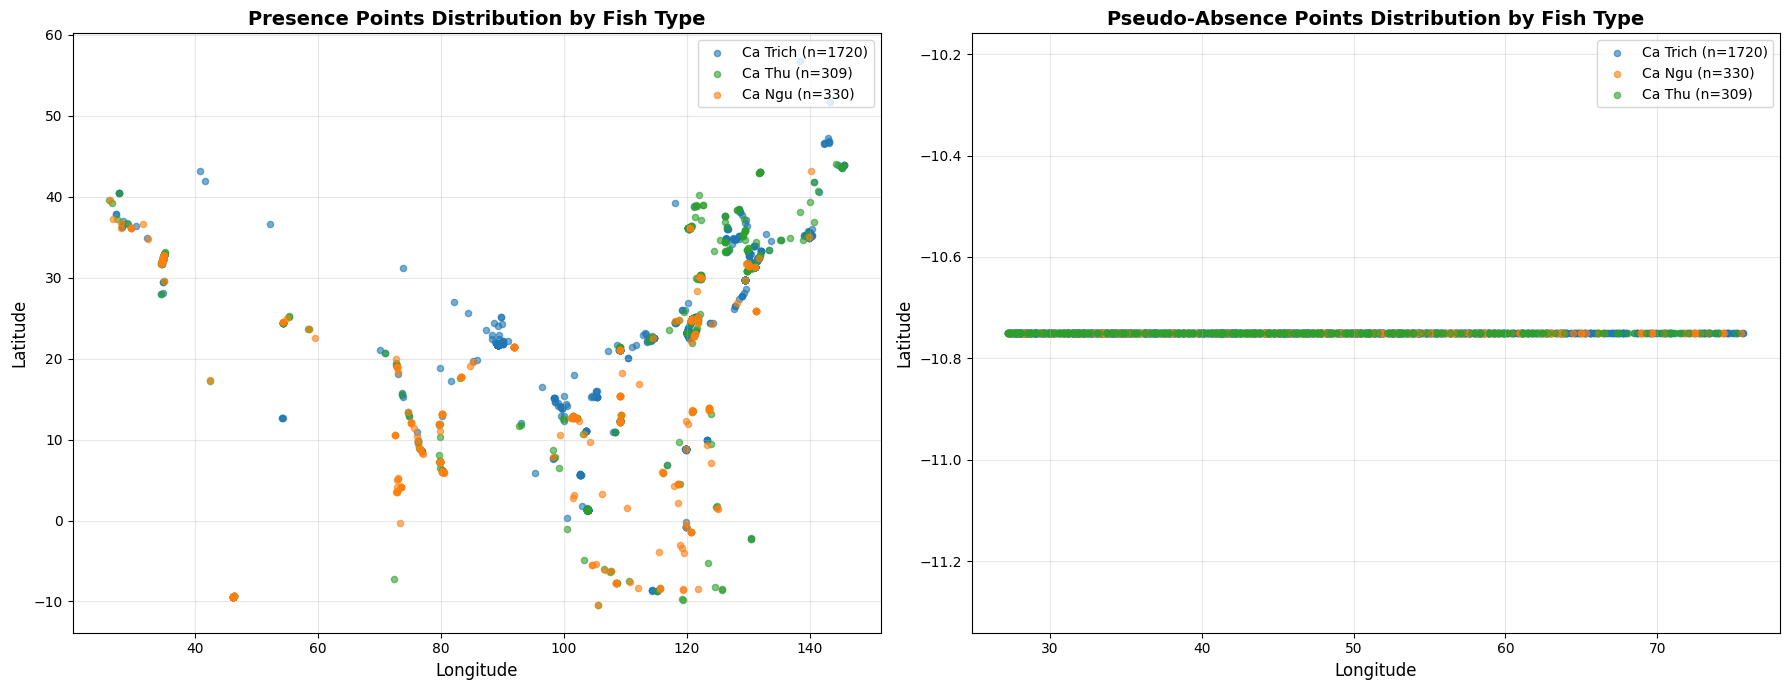

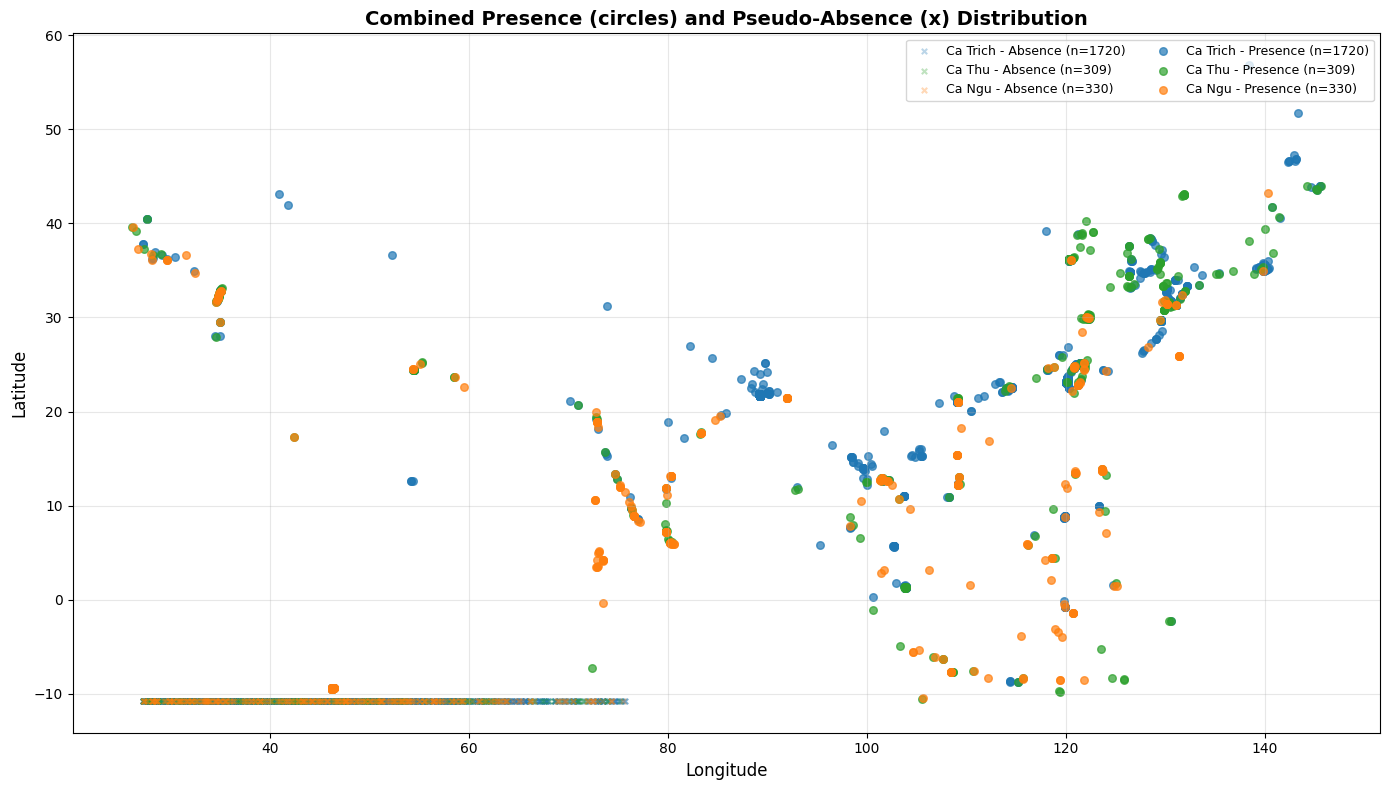


DISTRIBUTION SUMMARY

Ca Trich:
  Presences:  1720
  Absences:   1720
  Ratio:      1:1 ✓

Ca Thu:
  Presences:  309
  Absences:   309
  Ratio:      1:1 ✓

Ca Ngu:
  Presences:  330
  Absences:   330
  Ratio:      1:1 ✓


In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Visualize presence-absence map distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Define colors for each fish type
fish_colors = {
    'Ca Trich': '#1f77b4',  # blue
    'Ca Ngu': '#ff7f0e',    # orange
    'Ca Thu': '#2ca02c'     # green
}

# Plot 1: Presence points
ax1 = axes[0]
for fish_type in fish_df['fish_type'].unique():
    fish_data = sdm_points[(sdm_points['fish_type'] == fish_type) & (sdm_points['presence'] == 1)]
    ax1.scatter(fish_data['lon'], fish_data['lat'], 
               c=fish_colors[fish_type], alpha=0.6, s=20, 
               label=f'{fish_type} (n={len(fish_data)})')

ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.set_title('Presence Points Distribution by Fish Type', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Absence points
ax2 = axes[1]
for fish_type in absence_df['fish_type'].unique():
    fish_data = sdm_points[(sdm_points['fish_type'] == fish_type) & (sdm_points['presence'] == 0)]
    ax2.scatter(fish_data['lon'], fish_data['lat'], 
               c=fish_colors[fish_type], alpha=0.6, s=20, 
               label=f'{fish_type} (n={len(fish_data)})')

ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.set_title('Pseudo-Absence Points Distribution by Fish Type', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Combined visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Plot absences first (as background)
for fish_type in fish_df['fish_type'].unique():
    abs_data = sdm_points[(sdm_points['fish_type'] == fish_type) & (sdm_points['presence'] == 0)]
    ax.scatter(abs_data['lon'], abs_data['lat'], 
              c=fish_colors[fish_type], alpha=0.3, s=15, marker='x',
              label=f'{fish_type} - Absence (n={len(abs_data)})')

# Plot presences on top
for fish_type in fish_df['fish_type'].unique():
    pres_data = sdm_points[(sdm_points['fish_type'] == fish_type) & (sdm_points['presence'] == 1)]
    ax.scatter(pres_data['lon'], pres_data['lat'], 
              c=fish_colors[fish_type], alpha=0.7, s=30, marker='o',
              label=f'{fish_type} - Presence (n={len(pres_data)})')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Combined Presence (circles) and Pseudo-Absence (x) Distribution', 
            fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("DISTRIBUTION SUMMARY")
print("="*60)
for fish_type in fish_df['fish_type'].unique():
    pres_count = len(sdm_points[(sdm_points['fish_type'] == fish_type) & (sdm_points['presence'] == 1)])
    abs_count = len(sdm_points[(sdm_points['fish_type'] == fish_type) & (sdm_points['presence'] == 0)])
    print(f"\n{fish_type}:")
    print(f"  Presences:  {pres_count}")
    print(f"  Absences:   {abs_count}")
    print(f"  Ratio:      1:1 ✓")

In [43]:
# **Extract environmental features for each point**
# Updated for multi-label classification with fish_type encoding

**2. Data Preprocessing**

This section prepares data separately for CNN and LSTM models:
- **CNN Pipeline**: Extract spatial patches → Handle missing values → Min-Max normalization → Train/Test split (80/20 chronological) → DataLoader
- **LSTM Pipeline**: Extract temporal features → Handle missing values → Min-Max normalization → Train/Test split (80/20 chronological) → DataLoader
- **CNN-LSTM Model**: Uses both preprocessed datasets in parallel

In [44]:
# Encode fish_type as multi-label binary vectors
from sklearn.preprocessing import MultiLabelBinarizer

# For multi-label: each sample can have one fish_type (one-hot encoding)
fish_types = sdm_points['fish_type'].unique()
print(f"Fish types: {fish_types}")

# Create binary encoding for fish_type
mlb = MultiLabelBinarizer()
# Wrap each fish_type in a list for MultiLabelBinarizer
fish_type_encoded = mlb.fit_transform([[ft] for ft in sdm_points['fish_type']])

print(f"\nEncoded fish_type shape: {fish_type_encoded.shape}")
print(f"Classes: {mlb.classes_}")
print(f"\nExample encoding:")
for i in range(min(5, len(sdm_points))):
    print(f"  {sdm_points.iloc[i]['fish_type']} -> {fish_type_encoded[i]}")

# Prepare labels
y_presence = sdm_points['presence'].values
y_fish_type = fish_type_encoded

print(f"\ny_presence shape: {y_presence.shape}")
print(f"y_fish_type shape: {y_fish_type.shape}")

Fish types: ['Ca Trich' 'Ca Thu' 'Ca Ngu']

Encoded fish_type shape: (4718, 3)
Classes: ['Ca Ngu' 'Ca Thu' 'Ca Trich']

Example encoding:
  Ca Trich -> [0 0 1]
  Ca Trich -> [0 0 1]
  Ca Trich -> [0 0 1]
  Ca Trich -> [0 0 1]
  Ca Trich -> [0 0 1]

y_presence shape: (4718,)
y_fish_type shape: (4718, 3)


In [58]:
# Prepare chronological train/test split (80/20)
# Convert date to pandas Timestamp for proper sorting
sdm_points['date'] = pd.to_datetime(sdm_points['date'])

# Sort by date (chronological order: oldest to newest)
sdm_points_sorted = sdm_points.sort_values('date').reset_index(drop=True)
print(f"Date range: {sdm_points_sorted['date'].min()} to {sdm_points_sorted['date'].max()}")

# Calculate 80/20 split index
n_total = len(sdm_points_sorted)
n_train = int(n_total * 0.8)
n_test = n_total - n_train

print(f"\nTotal samples: {n_total}")
print(f"Train samples (80%): {n_train}")
print(f"Test samples (20%): {n_test}")

# Get split date for reference
split_date = sdm_points_sorted.iloc[n_train]['date']
print(f"Split date (80/20): {split_date}")

# Create train/test indices
train_indices = sdm_points_sorted.index[:n_train].tolist()
test_indices = sdm_points_sorted.index[n_train:].tolist()

# Create boolean masks
train_mask = np.array([i in train_indices for i in range(len(sdm_points_sorted))])
test_mask = np.array([i in test_indices for i in range(len(sdm_points_sorted))])

print(f"\nTrain mask sum: {train_mask.sum()}")
print(f"Test mask sum: {test_mask.sum()}")

Date range: 2020-01-02 00:00:00 to 2025-12-31 00:00:00

Total samples: 4718
Train samples (80%): 3774
Test samples (20%): 944
Split date (80/20): 2024-06-13 00:00:00

Train mask sum: 3774
Test mask sum: 944


In [59]:
## **2.1 CNN Data Preprocessing Pipeline**

In [60]:
def extract_spatial_patches(point_df, env_datasets, patch_size=8, time_idx=-1):
    """
    Extract spatial patches around each point for CNN.
    
    Args:
        point_df: DataFrame with 'lat', 'lon', 'presence', 'fish_type' columns
        env_datasets: Dict of xarray datasets
        patch_size: Size of spatial patch (patch_size x patch_size)
        time_idx: Time index to use (-1 for most recent)
    
    Returns:
        X: Spatial patches (N, C, H, W) where C = number of env variables
    """
    patches_list = []
    half_patch = patch_size // 2
    
    for idx, row in point_df.iterrows():
        lat, lon = row['lat'], row['lon']
        point_patches = []
        
        for var_name, ds in env_datasets.items():
            var = ds[list(ds.data_vars)[0]]
            
            # Select time if exists
            if 'time' in var.dims:
                var = var.isel(time=time_idx)
            
            # Handle depth dimension if present
            if 'depth' in var.dims:
                var = var.isel(depth=0)
            
            try:
                # Get coordinate names
                lat_coord = 'latitude' if 'latitude' in var.coords else 'lat'
                lon_coord = 'longitude' if 'longitude' in var.coords else 'lon'
                
                # Get nearest point indices
                lat_idx = np.abs(var[lat_coord].values - lat).argmin()
                lon_idx = np.abs(var[lon_coord].values - lon).argmin()
                
                # Extract patch with bounds checking
                lat_start = max(0, lat_idx - half_patch)
                lat_end = min(var.shape[-2], lat_idx + half_patch)
                lon_start = max(0, lon_idx - half_patch)
                lon_end = min(var.shape[-1], lon_idx + half_patch)
                
                patch = var.values[lat_start:lat_end, lon_start:lon_end]
                
                # Pad if needed to ensure consistent patch size
                if patch.shape != (patch_size, patch_size):
                    padded = np.full((patch_size, patch_size), np.nan)
                    padded[:patch.shape[0], :patch.shape[1]] = patch
                    patch = padded
                
                point_patches.append(patch)
            except Exception as e:
                # Fill with NaN if extraction fails
                point_patches.append(np.full((patch_size, patch_size), np.nan))
        
        # Stack patches: (n_channels, patch_size, patch_size)
        patches_list.append(np.stack(point_patches, axis=0))
    
    X = np.array(patches_list)  # (N, C, H, W)
    
    return X

# Extract spatial patches for CNN
print("Extracting spatial patches for CNN...")
X_cnn_raw = extract_spatial_patches(sdm_points_sorted, env_datasets, patch_size=8, time_idx=-1)

print(f"CNN X shape: {X_cnn_raw.shape}")  # (N, C, H, W)
print(f"Number of channels: {X_cnn_raw.shape[1]}")

Extracting spatial patches for CNN...
CNN X shape: (4718, 6, 8, 8)
Number of channels: 6


In [61]:
# CNN: Handle missing values (fill with 0 for land mask)
X_cnn_filled = np.nan_to_num(X_cnn_raw, nan=0.0)

print(f"CNN data after handling missing values: {X_cnn_filled.shape}")
print(f"Contains NaN: {np.isnan(X_cnn_filled).any()}")

CNN data after handling missing values: (4718, 6, 8, 8)
Contains NaN: False


In [62]:
# CNN: Min-Max normalization (channel-wise)
from sklearn.preprocessing import MinMaxScaler

N_cnn, C_cnn, H_cnn, W_cnn = X_cnn_filled.shape
X_cnn_normalized = np.zeros_like(X_cnn_filled)

for c in range(C_cnn):
    channel_data = X_cnn_filled[:, c, :, :].reshape(-1, 1)
    scaler_cnn = MinMaxScaler()
    channel_normalized = scaler_cnn.fit_transform(channel_data)
    X_cnn_normalized[:, c, :, :] = channel_normalized.reshape(N_cnn, H_cnn, W_cnn)

print(f"CNN data after Min-Max normalization: {X_cnn_normalized.shape}")
print(f"CNN data range: [{X_cnn_normalized.min():.4f}, {X_cnn_normalized.max():.4f}]")

CNN data after Min-Max normalization: (4718, 6, 8, 8)
CNN data range: [0.0000, 1.0000]


In [63]:
# CNN: Train/Test split (80/20 chronological)
# Split labels (already sorted by date in sdm_points_sorted)
y_presence_sorted = sdm_points_sorted['presence'].values
y_fish_type_sorted = mlb.transform([[ft] for ft in sdm_points_sorted['fish_type']])

# Apply train/test masks
X_cnn_train = X_cnn_normalized[train_mask]
X_cnn_test = X_cnn_normalized[test_mask]

y_cnn_presence_train = y_presence_sorted[train_mask]
y_cnn_presence_test = y_presence_sorted[test_mask]

y_cnn_fish_type_train = y_fish_type_sorted[train_mask]
y_cnn_fish_type_test = y_fish_type_sorted[test_mask]

print(f"CNN Training set:")
print(f"  X: {X_cnn_train.shape}")
print(f"  y_presence: {y_cnn_presence_train.shape}")
print(f"  y_fish_type: {y_cnn_fish_type_train.shape}")

print(f"\nCNN Test set:")
print(f"  X: {X_cnn_test.shape}")
print(f"  y_presence: {y_cnn_presence_test.shape}")
print(f"  y_fish_type: {y_cnn_fish_type_test.shape}")

print(f"\nCNN Presence distribution:")
print(f"  Train: {np.bincount(y_cnn_presence_train.astype(int))}")
print(f"  Test: {np.bincount(y_cnn_presence_test.astype(int))}")

CNN Training set:
  X: (3774, 6, 8, 8)
  y_presence: (3774,)
  y_fish_type: (3774, 3)

CNN Test set:
  X: (944, 6, 8, 8)
  y_presence: (944,)
  y_fish_type: (944, 3)

CNN Presence distribution:
  Train: [1905 1869]
  Test: [454 490]


In [64]:
# CNN: Convert to PyTorch tensors
X_cnn_train_tensor = torch.FloatTensor(X_cnn_train)
X_cnn_test_tensor = torch.FloatTensor(X_cnn_test)

y_cnn_presence_train_tensor = torch.FloatTensor(y_cnn_presence_train)
y_cnn_presence_test_tensor = torch.FloatTensor(y_cnn_presence_test)

y_cnn_fish_type_train_tensor = torch.FloatTensor(y_cnn_fish_type_train)
y_cnn_fish_type_test_tensor = torch.FloatTensor(y_cnn_fish_type_test)

print(f"CNN Tensors created:")
print(f"  X_train: {X_cnn_train_tensor.shape}")
print(f"  X_test: {X_cnn_test_tensor.shape}")
print(f"  y_presence_train: {y_cnn_presence_train_tensor.shape}")
print(f"  y_fish_type_train: {y_cnn_fish_type_train_tensor.shape}")

CNN Tensors created:
  X_train: torch.Size([3774, 6, 8, 8])
  X_test: torch.Size([944, 6, 8, 8])
  y_presence_train: torch.Size([3774])
  y_fish_type_train: torch.Size([3774, 3])


In [65]:
# CNN: Create DataLoaders
from torch.utils.data import TensorDataset, DataLoader

# Create datasets
cnn_train_dataset = TensorDataset(X_cnn_train_tensor, y_cnn_presence_train_tensor, y_cnn_fish_type_train_tensor)
cnn_test_dataset = TensorDataset(X_cnn_test_tensor, y_cnn_presence_test_tensor, y_cnn_fish_type_test_tensor)

# Create dataloaders
batch_size = 32
cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=batch_size, shuffle=True)
cnn_test_loader = DataLoader(cnn_test_dataset, batch_size=batch_size, shuffle=False)

print(f"CNN DataLoaders created:")
print(f"  Train batches: {len(cnn_train_loader)}")
print(f"  Test batches: {len(cnn_test_loader)}")
print(f"  Batch size: {batch_size}")

CNN DataLoaders created:
  Train batches: 118
  Test batches: 30
  Batch size: 32


In [66]:
## **2.2 LSTM Data Preprocessing Pipeline**

In [67]:
def extract_temporal_features(point_df, env_datasets, time_window=12):
    """
    Extract temporal environmental features for each point.
    
    Args:
        point_df: DataFrame with 'lat', 'lon', 'presence', 'fish_type' columns
        env_datasets: Dict of xarray datasets
        time_window: Number of time steps to extract
    
    Returns:
        X: Temporal features (N, T, F) where F = number of env variables
    """
    features_list = []
    
    for idx, row in point_df.iterrows():
        lat, lon = row['lat'], row['lon']
        point_features = []
        
        for var_name, ds in env_datasets.items():
            # Get the variable (first data variable in dataset)
            var = ds[list(ds.data_vars)[0]]
            
            # Select nearest point
            try:
                point_data = var.sel(latitude=lat, longitude=lon, method='nearest')
                
                # Get temporal data (last time_window steps)
                if 'time' in point_data.dims:
                    temporal_data = point_data.isel(time=slice(-time_window, None))
                    # Handle depth dimension if present
                    if 'depth' in temporal_data.dims:
                        temporal_data = temporal_data.isel(depth=0)
                    point_features.append(temporal_data.values)
                else:
                    # If no time dimension, repeat the value
                    point_features.append(np.repeat(point_data.values, time_window))
            except Exception as e:
                # Fill with NaN if extraction fails
                point_features.append(np.full(time_window, np.nan))
        
        # Stack features: (time_window, n_features)
        features_list.append(np.column_stack(point_features))
    
    X = np.array(features_list)  # (N, T, F)
    
    return X

# Extract features for all SDM points
print("Extracting temporal features for LSTM...")
X_lstm_raw = extract_temporal_features(sdm_points_sorted, env_datasets, time_window=12)

print(f"LSTM X shape: {X_lstm_raw.shape}")  # (N, T, F)
print(f"Number of environmental features: {X_lstm_raw.shape[2]}")

Extracting temporal features for LSTM...
LSTM X shape: (4718, 12, 6)
Number of environmental features: 6


In [68]:
# LSTM: Handle missing values (fill with 0 for land mask)
X_lstm_filled = np.nan_to_num(X_lstm_raw, nan=0.0)

print(f"LSTM data after handling missing values: {X_lstm_filled.shape}")
print(f"Contains NaN: {np.isnan(X_lstm_filled).any()}")

LSTM data after handling missing values: (4718, 12, 6)
Contains NaN: False


In [69]:
# LSTM: Min-Max normalization
from sklearn.preprocessing import MinMaxScaler

# Reshape for normalization: (N*T, F)
N_lstm, T_lstm, F_lstm = X_lstm_filled.shape
X_lstm_reshaped = X_lstm_filled.reshape(-1, F_lstm)

# Min-Max normalization
scaler_lstm = MinMaxScaler()
X_lstm_normalized = scaler_lstm.fit_transform(X_lstm_reshaped)

# Reshape back to (N, T, F)
X_lstm_normalized = X_lstm_normalized.reshape(N_lstm, T_lstm, F_lstm)

print(f"LSTM data after Min-Max normalization: {X_lstm_normalized.shape}")
print(f"LSTM data range: [{X_lstm_normalized.min():.4f}, {X_lstm_normalized.max():.4f}]")

LSTM data after Min-Max normalization: (4718, 12, 6)
LSTM data range: [0.0000, 1.0000]


In [70]:
# LSTM: Train/Test split (80/20 chronological)
# Apply train/test masks (same as CNN for consistency)
X_lstm_train = X_lstm_normalized[train_mask]
X_lstm_test = X_lstm_normalized[test_mask]

y_lstm_presence_train = y_presence_sorted[train_mask]
y_lstm_presence_test = y_presence_sorted[test_mask]

y_lstm_fish_type_train = y_fish_type_sorted[train_mask]
y_lstm_fish_type_test = y_fish_type_sorted[test_mask]

print(f"LSTM Training set:")
print(f"  X: {X_lstm_train.shape}")
print(f"  y_presence: {y_lstm_presence_train.shape}")
print(f"  y_fish_type: {y_lstm_fish_type_train.shape}")

print(f"\nLSTM Test set:")
print(f"  X: {X_lstm_test.shape}")
print(f"  y_presence: {y_lstm_presence_test.shape}")
print(f"  y_fish_type: {y_lstm_fish_type_test.shape}")

print(f"\nLSTM Presence distribution:")
print(f"  Train: {np.bincount(y_lstm_presence_train.astype(int))}")
print(f"  Test: {np.bincount(y_lstm_presence_test.astype(int))}")

LSTM Training set:
  X: (3774, 12, 6)
  y_presence: (3774,)
  y_fish_type: (3774, 3)

LSTM Test set:
  X: (944, 12, 6)
  y_presence: (944,)
  y_fish_type: (944, 3)

LSTM Presence distribution:
  Train: [1905 1869]
  Test: [454 490]


In [71]:
# LSTM: Convert to PyTorch tensors
X_lstm_train_tensor = torch.FloatTensor(X_lstm_train)
X_lstm_test_tensor = torch.FloatTensor(X_lstm_test)

y_lstm_presence_train_tensor = torch.FloatTensor(y_lstm_presence_train)
y_lstm_presence_test_tensor = torch.FloatTensor(y_lstm_presence_test)

y_lstm_fish_type_train_tensor = torch.FloatTensor(y_lstm_fish_type_train)
y_lstm_fish_type_test_tensor = torch.FloatTensor(y_lstm_fish_type_test)

print(f"LSTM Tensors created:")
print(f"  X_train: {X_lstm_train_tensor.shape}")
print(f"  X_test: {X_lstm_test_tensor.shape}")
print(f"  y_presence_train: {y_lstm_presence_train_tensor.shape}")
print(f"  y_fish_type_train: {y_lstm_fish_type_train_tensor.shape}")

LSTM Tensors created:
  X_train: torch.Size([3774, 12, 6])
  X_test: torch.Size([944, 12, 6])
  y_presence_train: torch.Size([3774])
  y_fish_type_train: torch.Size([3774, 3])


In [72]:
# LSTM: Create DataLoaders
from torch.utils.data import TensorDataset, DataLoader

# Create datasets
lstm_train_dataset = TensorDataset(X_lstm_train_tensor, y_lstm_presence_train_tensor, y_lstm_fish_type_train_tensor)
lstm_test_dataset = TensorDataset(X_lstm_test_tensor, y_lstm_presence_test_tensor, y_lstm_fish_type_test_tensor)

# Create dataloaders
batch_size = 32
lstm_train_loader = DataLoader(lstm_train_dataset, batch_size=batch_size, shuffle=True)
lstm_test_loader = DataLoader(lstm_test_dataset, batch_size=batch_size, shuffle=False)

print(f"LSTM DataLoaders created:")
print(f"  Train batches: {len(lstm_train_loader)}")
print(f"  Test batches: {len(lstm_test_loader)}")
print(f"  Batch size: {batch_size}")

LSTM DataLoaders created:
  Train batches: 118
  Test batches: 30
  Batch size: 32


## **2.3 Summary: Data Preprocessing Complete**

Both CNN and LSTM pipelines are ready:
- **Same source data**: `sdm_points_sorted` (chronologically ordered)
- **Same train/test split**: 80/20 based on date (oldest 80% for training)
- **Different preprocessing**: 
  - CNN: Spatial patches (8x8) with Min-Max normalization
  - LSTM: Temporal sequences (12 timesteps) with Min-Max normalization
- **Ready for training**: DataLoaders created for both models

# **3. Model Architecture**
- Model CNN for multi-label classification
- Model LSTM for multi-label classification
- Model CNN-LSTM parallel for multi-label classification

In [73]:
class SDM_CNN(nn.Module):
    """CNN model for multi-label classification (presence + fish type)"""
    def __init__(self, in_channels, num_fish_classes=3):
        super(SDM_CNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        
        # Adaptive pooling to handle variable input sizes
        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 2 * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        
        # Two output heads
        self.fc_presence = nn.Linear(64, 1)  # Binary presence/absence
        self.fc_fish_type = nn.Linear(64, num_fish_classes)  # Multi-label fish type
        
    def forward(self, x):
        # Conv block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout(x)
        
        # Conv block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        
        # Conv block 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive_pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        
        # Two outputs
        presence_out = self.fc_presence(x).squeeze()  # (batch,)
        fish_type_out = self.fc_fish_type(x)  # (batch, num_fish_classes)
        
        return presence_out, fish_type_out

# Initialize CNN model
in_channels = X_cnn_train_tensor.shape[1]
num_fish_classes = y_cnn_fish_type_train_tensor.shape[1]

cnn_model = SDM_CNN(in_channels=in_channels, num_fish_classes=num_fish_classes)

print(cnn_model)
print(f"\nInput channels: {in_channels}")
print(f"Number of fish classes: {num_fish_classes}")
print(f"Total parameters: {sum(p.numel() for p in cnn_model.parameters())}")

SDM_CNN(
  (conv1): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(2, 2))
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc_presence): Linear(in_features=64, out_features=1, bias=True)
  (fc_fish_type): Linear(in_features=64, out_features=3, bias=True)
)

Input channels: 6
Number of fish classes: 3
To

In [74]:
class SDM_LSTM(nn.Module):
    """LSTM model for multi-label classification (presence + fish type)"""
    def __init__(self, input_size, num_fish_classes=3, hidden_dim=64, num_layers=2, dropout=0.2):
        super(SDM_LSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.dropout = nn.Dropout(dropout)
        
        # Two output heads
        self.fc_presence = nn.Linear(32, 1)  # Binary presence/absence
        self.fc_fish_type = nn.Linear(32, num_fish_classes)  # Multi-label fish type
        
    def forward(self, x):
        # x: (batch, time, features)
        lstm_out, (hn, cn) = self.lstm(x)
        # Use last hidden state
        last_hidden = hn[-1]  # (batch, hidden_dim)
        x = F.relu(self.fc1(last_hidden))
        x = self.dropout(x)
        
        # Two outputs
        presence_out = self.fc_presence(x).squeeze()  # (batch,)
        fish_type_out = self.fc_fish_type(x)  # (batch, num_fish_classes)
        
        return presence_out, fish_type_out

# Initialize model
input_size = X_lstm_train_tensor.shape[2]  # Number of features
num_fish_classes = y_lstm_fish_type_train_tensor.shape[1]  # Number of fish types

lstm_model = SDM_LSTM(
    input_size=input_size, 
    num_fish_classes=num_fish_classes,
    hidden_dim=64, 
    num_layers=2, 
    dropout=0.2
)

print(lstm_model)
print(f"\nInput size: {input_size} features")
print(f"Number of fish classes: {num_fish_classes}")
print(f"Total parameters: {sum(p.numel() for p in lstm_model.parameters())}")

SDM_LSTM(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc_presence): Linear(in_features=32, out_features=1, bias=True)
  (fc_fish_type): Linear(in_features=32, out_features=3, bias=True)
)

Input size: 6 features
Number of fish classes: 3
Total parameters: 53924


In [75]:
class SDM_CNN_LSTM(nn.Module):
    """Parallel CNN-LSTM model for multi-label classification"""
    def __init__(self, cnn_channels, lstm_input_size, num_fish_classes=3, 
                 hidden_dim=64, num_layers=2, dropout=0.2):
        super(SDM_CNN_LSTM, self).__init__()
        
        # CNN branch
        self.conv1 = nn.Conv2d(cnn_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))
        self.cnn_fc = nn.Linear(64 * 2 * 2, 64)
        
        # LSTM branch
        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.lstm_fc = nn.Linear(hidden_dim, 64)
        
        # Fusion layers
        self.dropout = nn.Dropout(dropout)
        self.fusion_fc1 = nn.Linear(128, 64)  # 64 from CNN + 64 from LSTM
        self.fusion_fc2 = nn.Linear(64, 32)
        
        # Two output heads
        self.fc_presence = nn.Linear(32, 1)
        self.fc_fish_type = nn.Linear(32, num_fish_classes)
        
    def forward(self, x_cnn, x_lstm):
        # CNN branch
        cnn_out = self.pool(F.relu(self.bn1(self.conv1(x_cnn))))
        cnn_out = self.pool(F.relu(self.bn2(self.conv2(cnn_out))))
        cnn_out = self.adaptive_pool(cnn_out)
        cnn_out = cnn_out.view(cnn_out.size(0), -1)
        cnn_out = F.relu(self.cnn_fc(cnn_out))
        
        # LSTM branch
        lstm_out, (hn, cn) = self.lstm(x_lstm)
        lstm_out = F.relu(self.lstm_fc(hn[-1]))
        
        # Fusion
        fused = torch.cat([cnn_out, lstm_out], dim=1)
        fused = F.relu(self.fusion_fc1(fused))
        fused = self.dropout(fused)
        fused = F.relu(self.fusion_fc2(fused))
        fused = self.dropout(fused)
        
        # Two outputs
        presence_out = self.fc_presence(fused).squeeze()
        fish_type_out = self.fc_fish_type(fused)
        
        return presence_out, fish_type_out

# Initialize CNN-LSTM model
cnn_lstm_model = SDM_CNN_LSTM(
    cnn_channels=in_channels,
    lstm_input_size=input_size,
    num_fish_classes=num_fish_classes,
    hidden_dim=64,
    num_layers=2,
    dropout=0.2
)

print(cnn_lstm_model)
print(f"\nCNN input channels: {in_channels}")
print(f"LSTM input size: {input_size}")
print(f"Number of fish classes: {num_fish_classes}")
print(f"Total parameters: {sum(p.numel() for p in cnn_lstm_model.parameters())}")

SDM_CNN_LSTM(
  (conv1): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(2, 2))
  (cnn_fc): Linear(in_features=256, out_features=64, bias=True)
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (lstm_fc): Linear(in_features=64, out_features=64, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fusion_fc1): Linear(in_features=128, out_features=64, bias=True)
  (fusion_fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc_presence): Linear(in_features=32, out_features=1, bias=True)
  (fc_fish_type): Linear(in_features=32, out_features=3, bias=True)
)

CN